# Cats vs Dogs Classification with CNN

This notebook demonstrates the process of building a Convolutional Neural Network (CNN) for classifying images of cats and dogs. The notebook is organized into three main sections:

1. **Dataset Exploration**: Examining the dataset, visualizing images, and analyzing their properties
2. **Data Preprocessing**: Setting up data augmentation and preprocessing pipelines
3. **CNN Model**: Building, training, and evaluating a simple CNN model

## Setup and Imports


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from pathlib import Path
import pandas as pd
from PIL import Image
import imagesize
import torch.nn as nn
import torch.nn.functional as F
import itertools
from time import perf_counter
import os
import shutil
import glob
import matplotlib.pyplot as plt
import warnings
import random
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of CUDA devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"CUDA Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA is not available. This could be because:")
    print("1. Your PyTorch installation was not built with CUDA support")
    print("2. Your CUDA drivers are not properly installed or are incompatible")
    print("3. You don't have a CUDA-capable GPU")
    print("4. There might be an issue with environment variables")

print("Using device:", device)

PyTorch version: 2.3.1+cu121
CUDA available: True
CUDA version: 12.1
Number of CUDA devices: 1
CUDA Device 0: NVIDIA GeForce RTX 3090
Using device: cuda


In [3]:
torch.backends.cudnn.benchmark = True           # speed up convs for fixed image size
torch.set_float32_matmul_precision("high")      # small speedup on Ampere+

#Organize data into train, test and validation sets
notebook_dir = Path.cwd() #get current notebook dir

data_folder = notebook_dir.parent / "data" #create path to data folder

os.chdir(data_folder)

#create folders inside data
dirs = [
    "train/dog", "train/cat",
    "valid/dog", "valid/cat",
    "test/dog",  "test/cat"
]

for d in dirs:
    (data_folder / d).mkdir(parents=True, exist_ok=True)


#Base folders
target_folders = ["train", "valid", "test"]

#Create target folders if they don't exist
for split in target_folders:
    for cls in ["cat", "dog"]:
        folder = data_folder / split / cls
        folder.mkdir(parents=True, exist_ok=True)

#Source folders
cat_src = data_folder / "Cat"
dog_src = data_folder / "Dog"

#Function to move images randomly
def move_images(src_folder, dst_folder, n):
    imgs = list(src_folder.glob("*.jpg"))
    if not imgs:
        print(f"Warning: No images found in {src_folder}")
        return
    k = min(n, len(imgs))
    if k < n:
        print(f"Requested {n} images from {src_folder}, but only {len(imgs)} available. Sampling {k}.")
    sampled = random.sample(imgs, k)
    for img_path in sampled:
        shutil.copy2(str(img_path), dst_folder)

#Move images
move_images(cat_src, data_folder / "train" / "cat", 500)
move_images(dog_src, data_folder / "train" / "dog", 500)
move_images(cat_src, data_folder / "valid" / "cat", 100)
move_images(dog_src, data_folder / "valid" / "dog", 100)
move_images(cat_src, data_folder / "test" / "cat", 100)
move_images(dog_src, data_folder / "test" / "dog", 100)

## 1. Dataset Exploration
### Sample Images from the Dataset

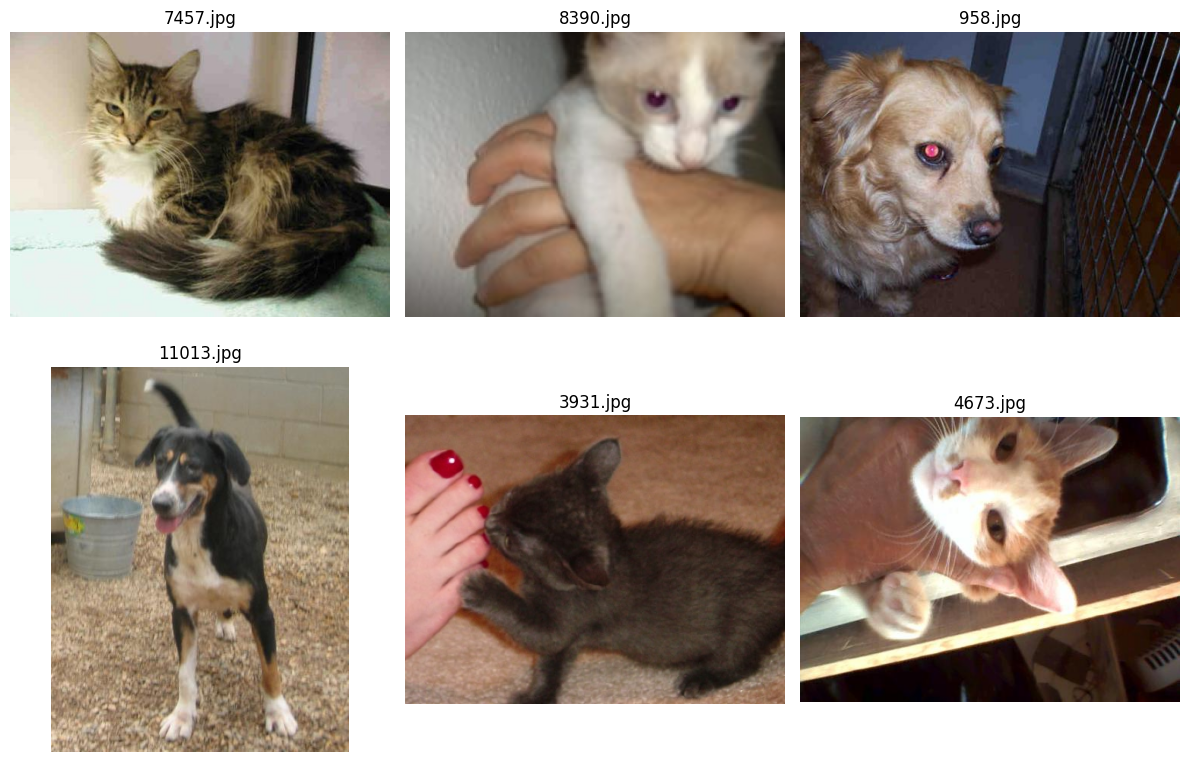

In [4]:

root = "../data/"

imgs = [img for img in Path(root).rglob("*.jpg")] #get all images from the subfolders

sampled = random.sample(imgs, 6)

plt.figure(figsize=(12, 8)) 
for i, filename in enumerate(sampled, 1):
     img_path = Path(root) / filename 
     img = Image.open(img_path) 
     plt.subplot(2, 3, i) 
     plt.imshow(img) 
     plt.axis("off") 
     plt.title(img_path.name) 
plt.tight_layout() 
plt.show()

### Image Size Analysis
Before we resize the images, let's analyze the dataset qualities:
- Size
- Width
- Height


In [5]:
sampled_imgs = random.sample(imgs, 3000)
img_meta = {}
for f in sampled_imgs: 
    img_meta[str(f)] = imagesize.get(f)  #Here we get the images resolution (f represents one image it is a path object)

#Convert into dataframe
img_meta_df = pd.DataFrame.from_dict([img_meta]).T.reset_index().set_axis(['FileName', 'Size'], axis='columns')
img_meta_df[["Width", "Height"]] = pd.DataFrame(img_meta_df["Size"].tolist(), index=img_meta_df.index)
img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)

print(f'Total Nr of Images in the dataset: {len(img_meta_df)}')
img_meta_df.head()


Total Nr of Images in the dataset: 3000


,FileName,Size,Width,Height,Aspect Ratio
0,..\data\Cat\2649.jpg,"(375, 500)",375,500,0.75
1,..\data\train\dog\1807.jpg,"(367, 500)",367,500,0.73
2,..\data\Dog\3427.jpg,"(500, 387)",500,387,1.29
3,..\data\Cat\9547.jpg,"(500, 375)",500,375,1.33
4,..\data\Dog\3172.jpg,"(500, 411)",500,411,1.22


Text(0, 0.5, 'Height')

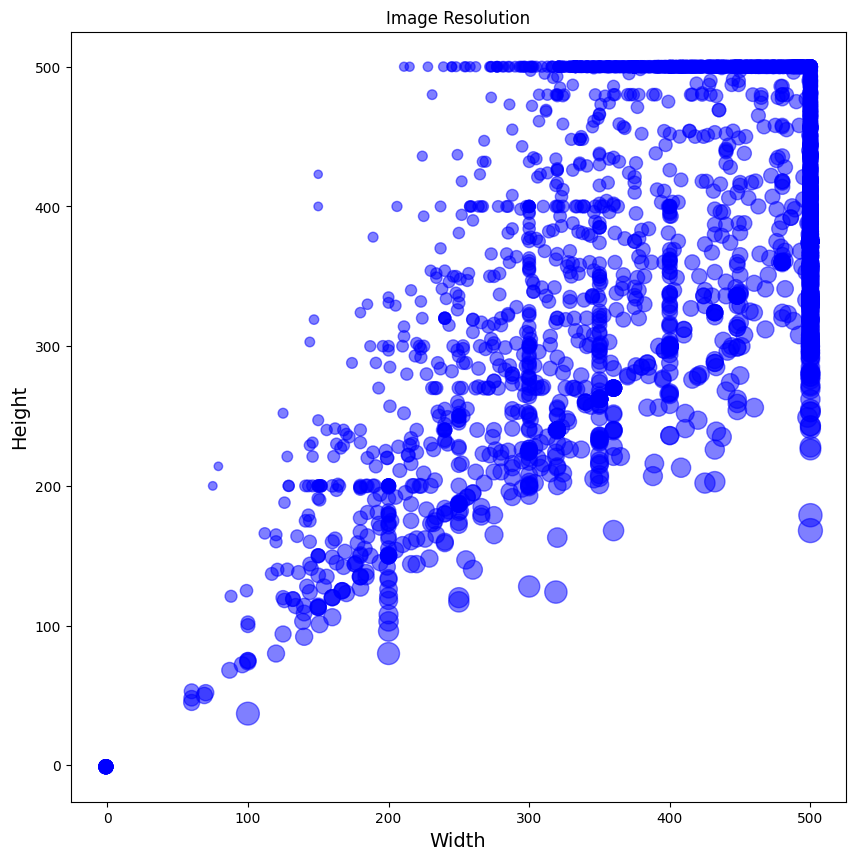

In [6]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
points = ax.scatter(img_meta_df.Width, img_meta_df.Height, color='blue', alpha=0.5, s=img_meta_df["Aspect Ratio"]*100, picker=True)
ax.set_title("Image Resolution")
ax.set_xlabel("Width", size=14)
ax.set_ylabel("Height", size=14)

### Image Resolution Analysis
These results show us that many of the images have a quadratic form. We can resize them without much cropping or padding.

### Pixel Intensity Distribution
50 sampled images; 0=black, 255=white; it seems to be a normal distribution without missing ranges.


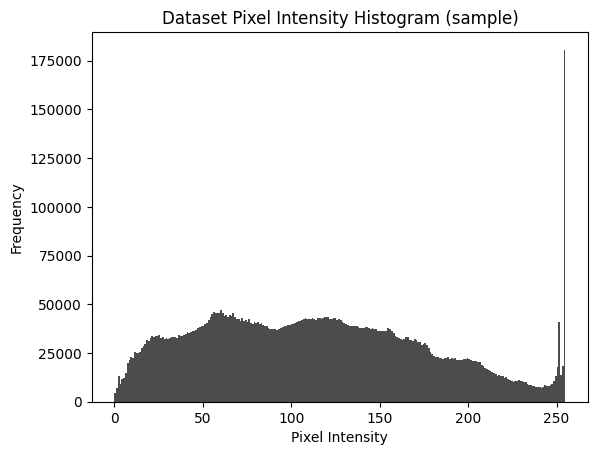

In [7]:
imgs = random.sample(imgs, 50)

all_pixels = []

for img_path in imgs:
    img = Image.open(img_path).convert("L")
    pixels = np.array(img).flatten()
    all_pixels.extend(pixels)

plt.hist(all_pixels, bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title("Dataset Pixel Intensity Histogram (sample)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


## 2. Data Preprocessing
### PyTorch Preprocessing Pipeline
Images are resized/cropped to 224x224. Augmentations are applied to the training set only.

Classes: ['cat', 'dog']
Class to index: {'cat': 0, 'dog': 1}
Train/Valid/Test sizes: 1000/200/200
Batch tensor shape: torch.Size([256, 3, 224, 224])


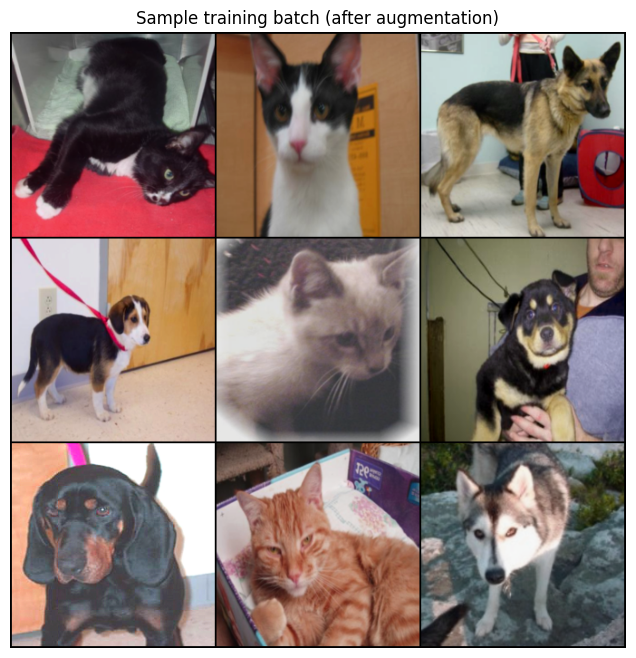

In [8]:
# Configuration parameters
BATCH_TRAIN = 256  # try 128 or 256
BATCH_VAL = 256
IMG_SIZE = 224
EPOCHS = 60
PATIENCE = 7
LR = 3e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTH = 0.05
NUM_WORKERS = min(8, os.cpu_count())

# Normalization (ImageNet stats work well for RGB natural images)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Data augmentation for training (gentler)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    normalize,
])

# Validation/Test: no augmentation, deterministic
inference_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    normalize,
])

# Datasets
train_dir = data_folder / "train"
valid_dir = data_folder / "valid"
test_dir  = data_folder / "test"

train_ds = datasets.ImageFolder(str(train_dir), transform=train_transform)
valid_ds = datasets.ImageFolder(str(valid_dir), transform=inference_transform)
test_ds  = datasets.ImageFolder(str(test_dir),  transform=inference_transform)

# DataLoaders
pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=True, prefetch_factor=4
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=True, prefetch_factor=4
)
test_loader  = DataLoader(
    test_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=True, prefetch_factor=4
)

print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)
print(f"Train/Valid/Test sizes: {len(train_ds)}/{len(valid_ds)}/{len(test_ds)}")

# Visualize a training batch
images, labels = next(iter(train_loader))
print("Batch tensor shape:", images.shape)

# Convert back to [0,1] for display from normalized tensors
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

imgs_show = inv_normalize(images.clone())
grid = make_grid(imgs_show[:9], nrow=3, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Sample training batch (after augmentation)")
plt.show()

### Preprocessing Adequacy Check

The current PyTorch preprocessing is appropriate for a Cats vs Dogs CNN:

- Deterministic validation/test pipeline: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize.
- Training-time augmentation: RandomResizedCrop, HorizontalFlip, small Rotation, ColorJitter, and GaussianBlur. These improve generalization without changing labels.
- Normalization: ImageNet mean/std, which is standard for RGB natural images. Alternatively, you can compute dataset-specific stats later.
- Batch visualization included to sanity-check augmentations and labels.


## 3. CNN: Model, Training, and Evaluation
### Model Architecture

In [9]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2), nn.Dropout(0.10),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2), nn.Dropout(0.20),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2), nn.Dropout(0.30),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.head(self.feat(x))

num_classes = len(train_ds.classes)
model = SimpleCNN(num_classes=num_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

SimpleCNN(
  (feat): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.2, inplac

### Training and Validation Process

In [10]:

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def run_epoch(model, loader, criterion, device, train: bool):
    if train:
        model.train()
    else:
        model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(x)
                loss = criterion(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        # Detach and move to CPU before computing accuracy
        total_acc  += accuracy_from_logits(logits.detach(), y.detach()) * bs
        total_n    += bs

        # Clean up tensors to free GPU memory
        del logits, loss

    return total_loss/total_n, total_acc/total_n

# Initialize GradScaler for mixed precision training
scaler = torch.cuda.amp.GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state = None
no_improve = 0
start = perf_counter()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, train=True)
    va_loss, va_acc = run_epoch(model, valid_loader, criterion, device, train=False)
    scheduler.step(va_loss)  # Pass validation loss to ReduceLROnPlateau

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    # Clean up GPU memory
    torch.cuda.empty_cache()

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {va_loss:.4f}, acc {va_acc:.3f}")

    # early stopping on val_acc
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement {PATIENCE} epochs).")
            break

end = perf_counter()

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

print(f"Training finished in {(end-start):.1f}s. Best val acc: {best_val_acc:.3f}")

# --- Evaluate on TEST set and print % ---
model.eval()

@torch.no_grad()
def accuracy_on(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
        # free
        del logits, preds, x, y
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

test_acc = accuracy_on(test_loader)
val_acc  = accuracy_on(valid_loader)   # (optional) to show final val as well

print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Test Accuracy:       {test_acc*100:.2f}%")


Epoch 01 | train loss 0.6733, acc 0.570 | val loss 0.6933, acc 0.500
Epoch 02 | train loss 0.6488, acc 0.619 | val loss 0.6948, acc 0.480
Epoch 03 | train loss 0.6351, acc 0.635 | val loss 0.6981, acc 0.500
Epoch 04 | train loss 0.6307, acc 0.645 | val loss 0.7118, acc 0.500
Epoch 05 | train loss 0.6213, acc 0.639 | val loss 0.7391, acc 0.500
Epoch 06 | train loss 0.6074, acc 0.661 | val loss 0.7484, acc 0.505
Epoch 07 | train loss 0.6140, acc 0.666 | val loss 0.7332, acc 0.515
Epoch 08 | train loss 0.6012, acc 0.671 | val loss 0.7186, acc 0.540
Epoch 09 | train loss 0.6004, acc 0.675 | val loss 0.7146, acc 0.570
Epoch 10 | train loss 0.5911, acc 0.683 | val loss 0.6960, acc 0.570
Epoch 11 | train loss 0.5909, acc 0.676 | val loss 0.6802, acc 0.580
Epoch 12 | train loss 0.5999, acc 0.681 | val loss 0.6664, acc 0.595
Epoch 13 | train loss 0.5898, acc 0.690 | val loss 0.6591, acc 0.605
Epoch 14 | train loss 0.5872, acc 0.698 | val loss 0.6571, acc 0.590
Epoch 15 | train loss 0.5885, acc 

### Learning Curves Visualization

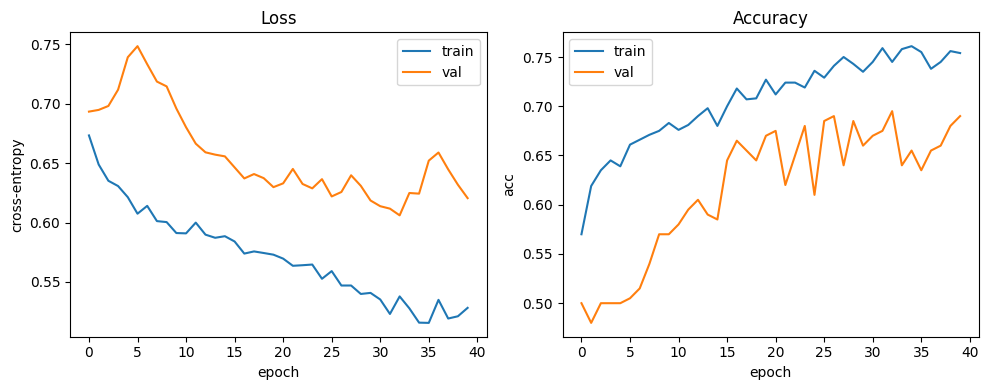

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.ylabel('cross-entropy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='train')
plt.plot(val_accs, label='val')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend()
plt.tight_layout()
plt.show()

### Test Set Evaluation and Predictions

Cat-only test accuracy: 0.770


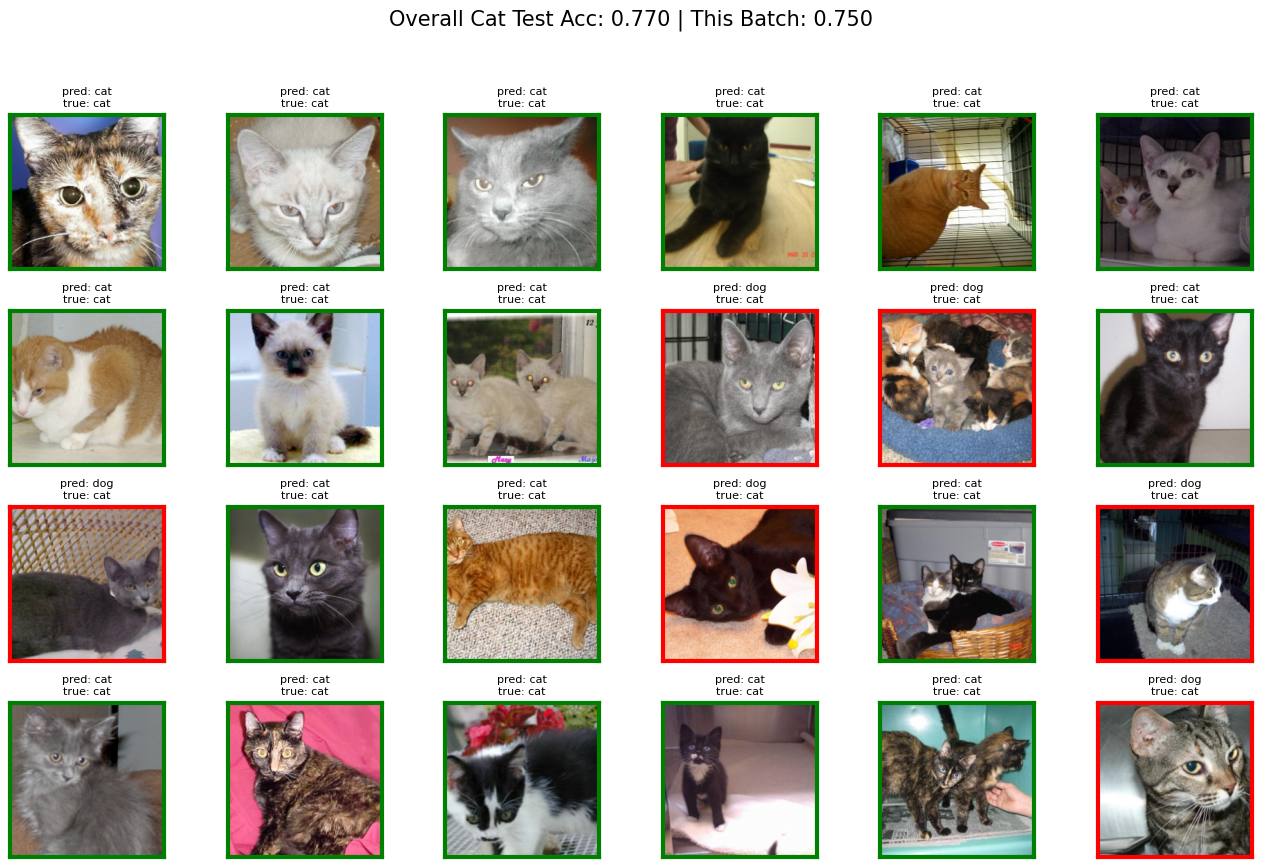

In [20]:
# ==== Visualize CAT images only ====

SHOW_RANDOM = True  # False = same pics every run

model.eval()
device = next(model.parameters()).device

# Reuse dataset from your existing test_loader
test_ds = getattr(test_loader, "dataset", None)
assert test_ds is not None, "test_loader.dataset not found."

# Find the 'cat' class index robustly
classes = test_ds.classes
cat_idx_candidates = [i for i, c in enumerate(classes) if "cat" in c.lower()]
cat_idx = cat_idx_candidates[0] if cat_idx_candidates else (0 if len(classes) == 2 else 0)

# Build a DataLoader that samples ONLY cat images
cat_indices = [i for i, t in enumerate(getattr(test_ds, "targets", [])) if t == cat_idx]
assert len(cat_indices) > 0, "No cat images found in the test set."

cat_sampler = SubsetRandomSampler(cat_indices)
cat_loader = DataLoader(
    test_ds,
    batch_size=48,              # you can change this
    sampler=cat_sampler,
    num_workers=getattr(test_loader, "num_workers", 4),
    pin_memory=True,
)

# Inverse normalization (same stats you used)
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# ---- Evaluate overall cat-only test accuracy (optional) ----
@torch.no_grad()
def cat_only_accuracy(model, loader, device, cat_idx):
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu()
        y_cpu = y.cpu()
        correct += (preds == y_cpu).sum().item()  # y_cpu are all cat_idx
        total += y_cpu.size(0)
        del logits, x
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

cat_test_acc = cat_only_accuracy(model, cat_loader, device, cat_idx)
print(f"Cat-only test accuracy: {cat_test_acc:.3f}")

# ---- Visualize a single CATS-ONLY batch ----
if SHOW_RANDOM:
    images, labels = random.choice(list(cat_loader))  # all labels == cat_idx
else:
    images, labels = next(iter(cat_loader))  # all labels == cat_idx

with torch.no_grad():
    logits = model(images.to(device, non_blocking=True))
    preds = torch.argmax(logits, dim=1).detach().cpu()
del logits
torch.cuda.empty_cache()

# Batch accuracy (cats only)
batch_acc = (preds == labels).float().mean().item()

# Prepare images for display
imgs_show = inv_normalize(images)
rows, cols = 4, 6   # 24 images grid
n_show = min(rows * cols, images.size(0))

fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
fig.suptitle(
    f"Overall Cat Test Acc: {cat_test_acc:.3f} | This Batch: {batch_acc:.3f}",
    fontsize=15
)
axes = np.array(axes).reshape(-1)
for i in range(n_show):
    ax = axes[i]
    ax.imshow(imgs_show[i].permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
    is_correct = (preds[i].item() == labels[i].item())
    color = 'green' if is_correct else 'red'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[labels[i]]}", fontsize=8)

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Dog-only test accuracy: 0.640


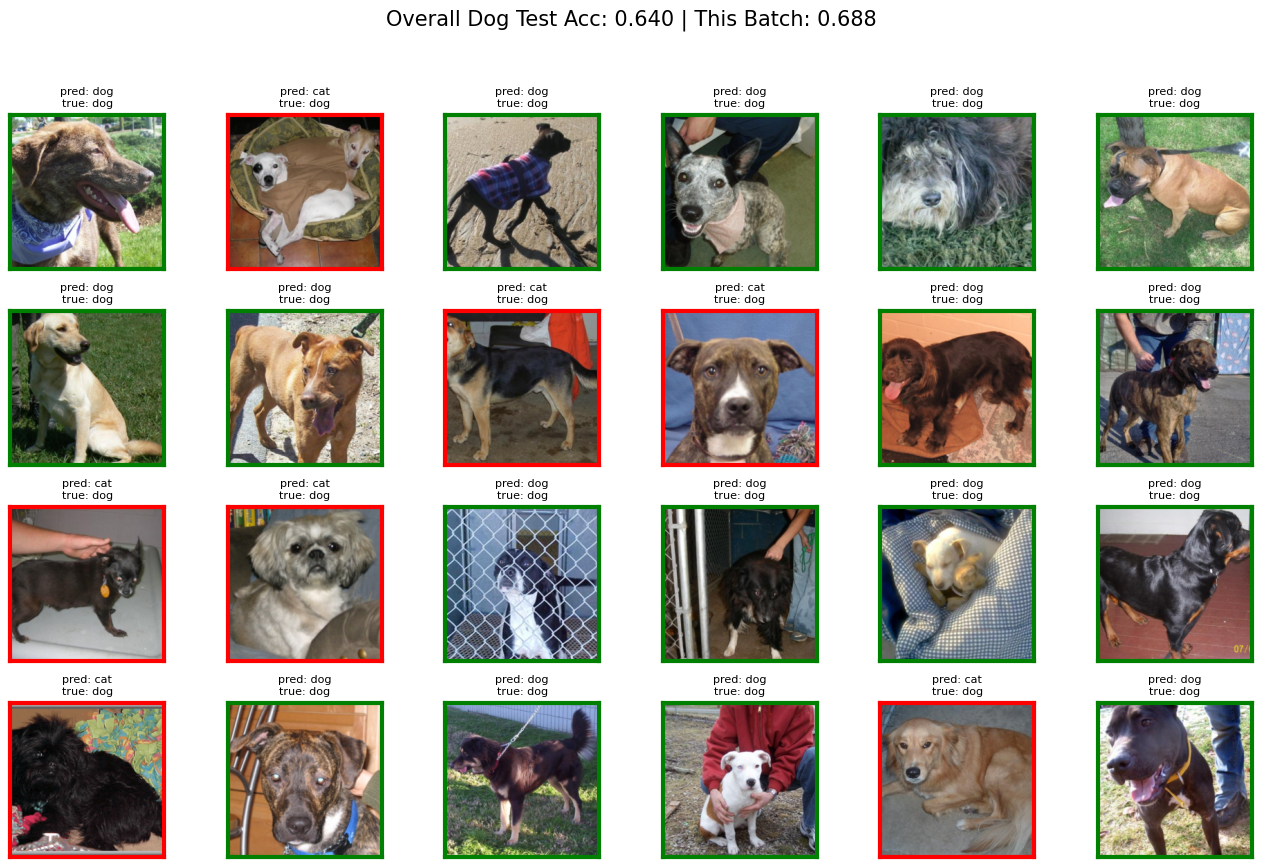

In [21]:
# ==== Visualize DOG images only ====

SHOW_RANDOM = True  # False = same pics every run

if SHOW_RANDOM:
    images, labels = random.choice(list(test_loader))
else:
    images, labels = next(iter(test_loader))

model.eval()
device = next(model.parameters()).device

# Reuse dataset from your existing test_loader
test_ds = getattr(test_loader, "dataset", None)
assert test_ds is not None, "test_loader.dataset not found."

# Find the 'dog' class index robustly
classes = test_ds.classes
dog_idx_candidates = [i for i, c in enumerate(classes) if "dog" in c.lower()]
dog_idx = dog_idx_candidates[0] if dog_idx_candidates else (1 if len(classes) == 2 else 0)

# Build a DataLoader that samples ONLY dog images
dog_indices = [i for i, t in enumerate(getattr(test_ds, "targets", [])) if t == dog_idx]
assert len(dog_indices) > 0, "No dog images found in the test set."

dog_sampler = SubsetRandomSampler(dog_indices)
dog_loader = DataLoader(
    test_ds,
    batch_size=48,              # you can change this
    sampler=dog_sampler,
    num_workers=getattr(test_loader, "num_workers", 4),
    pin_memory=True,
)

# Inverse normalization (same stats you used)
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# ---- Evaluate overall dog-only test accuracy (optional) ----
@torch.no_grad()
def dog_only_accuracy(model, loader, device, dog_idx):
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu()
        y_cpu = y.cpu()
        correct += (preds == y_cpu).sum().item()  # y_cpu are all dog_idx
        total += y_cpu.size(0)
        del logits, x
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

dog_test_acc = dog_only_accuracy(model, dog_loader, device, dog_idx)
print(f"Dog-only test accuracy: {dog_test_acc:.3f}")

# ---- Visualize a single DOGS-ONLY batch ----
images, labels = next(iter(dog_loader))  # all labels == dog_idx
with torch.no_grad():
    logits = model(images.to(device, non_blocking=True))
    preds = torch.argmax(logits, dim=1).detach().cpu()
del logits
torch.cuda.empty_cache()

# Batch accuracy (dogs only)
batch_acc = (preds == labels).float().mean().item()

# Prepare images for display
imgs_show = inv_normalize(images)
rows, cols = 4, 6   # 24 images grid
n_show = min(rows * cols, images.size(0))

fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
fig.suptitle(
    f"Overall Dog Test Acc: {dog_test_acc:.3f} | This Batch: {batch_acc:.3f}",
    fontsize=15
)
axes = np.array(axes).reshape(-1)
for i in range(n_show):
    ax = axes[i]
    ax.imshow(imgs_show[i].permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
    is_correct = (preds[i].item() == labels[i].item())
    color = 'green' if is_correct else 'red'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[labels[i]]}", fontsize=8)

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


TEST accuracy: 0.705
              precision    recall  f1-score   support

         cat       0.68      0.77      0.72       100
         dog       0.74      0.64      0.68       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



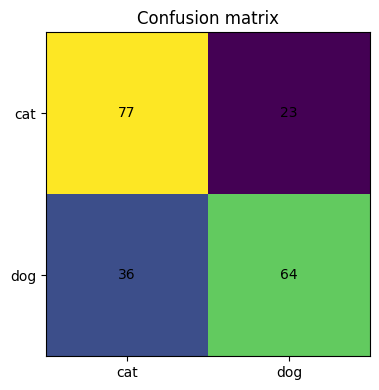

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np, matplotlib.pyplot as plt

model.eval()
all_y, all_p = [], []
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        all_p.append(pred); all_y.append(y.numpy())
y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)

print("TEST accuracy:", (y_true==y_pred).mean())
print(classification_report(y_true, y_pred, target_names=test_loader.dataset.classes))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm, interpolation='nearest'); ax.set_title('Confusion matrix')
ax.set_xticks(range(len(cm))); ax.set_yticks(range(len(cm)))
ax.set_xticklabels(test_loader.dataset.classes); ax.set_yticklabels(test_loader.dataset.classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha='center', va='center')
plt.tight_layout(); plt.show()
